In [1]:
import numpy as np
from dynesty import NestedSampler
from dynesty import utils as dyfunc
import matplotlib.pyplot as plt
import corner

In [14]:

# -------------------------------
# Eggbox definition
# -------------------------------

# Prior bounds
prior_min, prior_max = 0.0, 10.0 * np.pi
prior_volume = (prior_max - prior_min) ** 2  # for reference

# True evidence from the literature
true_logz = 235.856


def loglikelihood(theta):
    """
    Eggbox log-likelihood.
    theta: array of shape (2,)
    """
    x, y = theta
    return (2.0 + np.cos(x / 2.0) * np.cos(y / 2.0)) ** 5


def prior_transform(u):
    """
    Transform from unit cube [0,1]^2 to parameter space [0, 10π]^2.
    """
    x = prior_min + (prior_max - prior_min) * u[0]
    y = prior_min + (prior_max - prior_min) * u[1]
    return np.array([x, y])


# -------------------------------
# Run dynesty Nested Sampling
# -------------------------------

# 2 parameters
ndim = 2

# Set up the sampler
sampler = NestedSampler(
    loglikelihood,
    prior_transform,
    ndim,
    nlive=100,       # number of live points; increase for accuracy
    sample="rwalk",  # random-walk proposals; can try "unif", "slice"
    bound="multi",   # bounding method ("multi" good for multimodal)
)

print("Running dynesty Nested Sampling on Eggbox...")
sampler.run_nested(print_progress=True)
res = sampler.results
samples, weights = res.samples, np.exp(res.logwt - res.logz[-1])
posterior_samples = dyfunc.resample_equal(samples, weights)
# -------------------------------
# Report results
# -------------------------------
logZ, logZerr = res.logz[-1], res.logzerr[-1]

print("\n==== RESULTS ====")
print(f"dynesty estimated logZ = {logZ:.3f} ± {logZerr:.3f}")
print(f"True logZ (literature) = {true_logz:.3f}")
print(f"Error = {logZ - true_logz:.3f}")


Running dynesty Nested Sampling on Eggbox...


900it [00:00, 1361.52it/s, +100 | bound: 42 | nc: 1 | ncall: 16182 | eff(%):  6.218 | loglstar:   -inf < 243.000 <    inf | logz: 236.311 +/-  0.237 | dlogz:  0.001 >  0.109]


==== RESULTS ====
dynesty estimated logZ = 236.311 ± 0.283
True logZ (literature) = 235.856
Error = 0.455


In [18]:
from nismo import CallableModel, NISMOSampler, MorphProposal, EnsembleRWalkSettings, RWalkSettings
from nismo.diagnostics import summarize
from nismo.plotting import plot_run, plot_weight_health
from nismo import StoppingCriterionConfig, StoppingPolicy

stopping = StoppingPolicy(
    criteria=(
        StoppingCriterionConfig(
            name="live_logz_error",
            tolerance=5e-3,
        ),
        StoppingCriterionConfig(
            name="remaining_fraction",
            tolerance=5e-2,
        ),
        StoppingCriterionConfig(
            name="logz_stability",
            tolerance=5e-3,
        ),
    ),
    mode="all",
    consecutive=3,
    min_iterations=10,
    stability_window=10,
)

def logprior(theta):
    x, y = theta
    if prior_min <= x <= prior_max and prior_min <= y <= prior_max:
        return -np.log(prior_volume)
    return -np.inf

model = CallableModel(
    ndim=2,
    parameter_names=("x", "y"),
    log_likelihood_fn=loglikelihood,
    log_prior_fn=logprior,
    vectorized=False,
)
importance_dist = MorphProposal.fit(
    posterior_samples,
    param_names=model.parameter_names,
    morph_type="2_group",
    kde_bw="silverman",
)
# nismo_sampler = NISMOSampler(
#     model=model,
#     importance_morph=importance_dist,
#     proposal_scheme="rwalk",
#     rwalk_settings=RWalkSettings(
#         walks=100,
#         # scale=None uses 2.38 / sqrt(ndim)
#     ),
#     n_live=200,
#     rng=1234,

# )
nismo_sampler = NISMOSampler(
    model=model,
    importance_morph=importance_dist,
    proposal_scheme="en-rwalk",
    ensemble_rwalk_settings=EnsembleRWalkSettings(
        n_walkers=100,
        n_sweeps=4,
        # gamma=None uses 2.38 / sqrt(2 * ndim)
    ),
    n_live=500,
    rng=1234,

)

nismo_result = nismo_sampler.run(
    dlogz=0.01,
    max_iterations=200_000,
    max_proposals_per_replacement=500_000,
    max_likelihood_calls=10_000_000,
    progress=True
)

MI pairs:   0%|          | 0/1 [00:00<?, ?it/s]

NISMO nlive=500: 0it [00:00, ?it/s]

/home/apokrypha/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


In [19]:
diagnostics = summarize(nismo_result)

print("NISMO success:", nismo_result.success)
print("Termination:", nismo_result.termination_reason)
print(f"NISMO logZ:    {nismo_result.logz:.3f} ± {nismo_result.logzerr:.3f}")
print(f"Dynesty logZ: {res.logz[-1]:.3f} ± {res.logzerr[-1]:.3f}")
print(f"Reference:    {true_logz:.3f}")
print("Iterations:", nismo_result.niter)
print("Likelihood calls:", nismo_result.n_likelihood_calls)
print("Diagnostics:", diagnostics)

for warning in nismo_result.warnings:
    print("WARNING:", warning)

NISMO success: True
Termination: remaining_evidence
NISMO logZ:    235.363 ± 0.113
Dynesty logZ: 236.311 ± 0.283
Reference:    235.856
Iterations: 6672
Likelihood calls: 801140
Diagnostics: RunDiagnostics(posterior_ess=3084.5773523113808, relative_posterior_ess=0.43008607812484395, proposal_acceptance_fraction=0.008333333333333333, maximum_proposals_per_replacement=120, thresholds_monotone=False, conservative_log_remaining=230.76552253529965, final_remaining_fraction=0.009935377990672956, final_remaining_dlogz=0.00998506322690965, final_live_ess=499.96869727976593, final_live_mean_rse=0.00035421696688446466, final_live_logz_error=3.5192794567068413e-06, final_logz_stability=5.906688613777078e-07, final_stopping_streak=1)


(5000, 2)


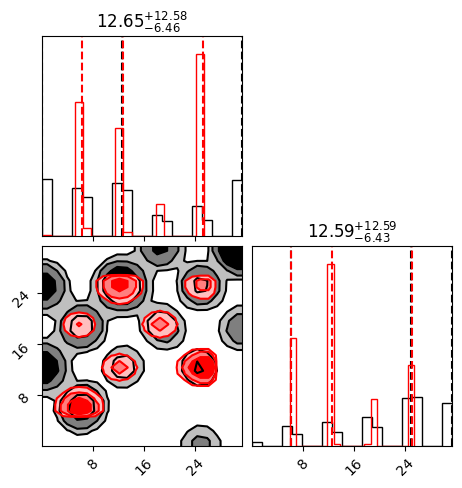

In [20]:
equal_samples = nismo_result.resample_equal(
    rng=123,          # required for reproducibility
    n_samples=5000,
)

print(equal_samples.shape)  # (10000, ndim)

fig = corner.corner(
    posterior_samples[::2,:], bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
corner.corner(
    equal_samples[::2,:],color="red", bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fig=fig,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
plt.show()